# RNN From Scratch

## Why need RNN?

We have a sentence "I am learning deep learning"

- FNN could process each word, but it doesn't naturally remember what came before.
- RNN processes the sequence one element at a time.


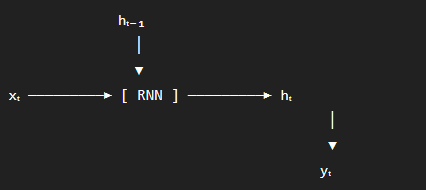

x_t = input at current time step

h_t-1 = previous hidden state

h_t = new hidden state

y_t = output

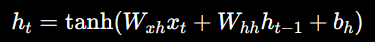

W_xh  -> weight for x for current hidden state

x_t   -> current input

W_hh  -> weight for h for current hidden state

h_t-1 -> previous hiddent state

b_h   -> bais for current hidden state

In [101]:
import numpy as np
import matplotlib.pyplot as plt

In [102]:
# Many to one RNN

# Think of this data as a embedding of some text

X = [
    [1.0, 0.5],
    [0.5, 1.0],
    [1.0, 1.5],
    [1.5, 1.0]
]

X = np.array(X)

target = 1

X

array([[1. , 0.5],
       [0.5, 1. ],
       [1. , 1.5],
       [1.5, 1. ]])

In [103]:
# Parameters

h = np.zeros(X.shape[1]) # output [0, 0]

# weight for x
W_xh = np.array([
    [0.5, 0.2],
    [0.3, 0.4]
])

# weight for h
W_hh = np.array([
    [0.1, 0.3],
    [0.2, 0.4]
])

# why the weights are 2x2 instead of 2x1
# becuse when we to matrix mul 2x1 @ 2x1 will missmatch so we put 2x2 so 2x2 @ 2x1 will produce 2x1

# bais for h
b_h = np.array([0.1, 0.2])

# weight for output y
W_hy = np.array([
    [0.5, 0.3],
    [0.2, 0.4]
])

# bais for y
b_y = np.array([0.1, 0.2])

# Learning Rate
lr = 0.01


In [104]:
def RNN_forward(X, h, W_xh, W_hh, b_h, W_hy, b_y):

    # storing all the hidden states
    hidden_states = []

    hidden_states.append(h)

    # for each x in X
    for t in range(len(X)):

        # Forward pass
        h = np.tanh((W_xh @ X[t]) + (W_hh @ h) + b_h)

        # storing all the hidden state
        hidden_states.append(h)

    # print("Hidden states:", hidden_states)

    # final prediction using last hidden state beacuse its many to one

    def softmax(z):
        return np.exp(z)/np.sum(np.exp(z))

    z = (W_hy @ h) + b_y

    y = softmax(z)

    # print("final output:", y)

    return y, hidden_states

y, hidden_states = RNN_forward(X, h, W_xh, W_hh, b_h, W_hy, b_y)

# Loss Function

In [105]:
def CrossEntropyLoss(y, target):
    return -np.log(y[target])

loss = CrossEntropyLoss(y, target)

# Backpropagation Output Layer and (BPTT)

In [106]:
# ============================================================
# BACKPROPAGATION - OUTPUT LAYER + FINAL RNN STEP
# ============================================================

def RNN_backward(X, h, W_xh, W_hh, b_h, W_hy, b_y, y, target, loss):

    # One-hot target

    one_hot_target = np.zeros(2)
    one_hot_target[target] = 1

    # Softmax + Cross Entropy

    # L = -log(y[target])
    # dL/dz = y - target

    dl_dz = y - one_hot_target

    # Output layer
    # z = W_hy @ h_4 + b_y

    # dL/dW_hy
    dl_dW_hy = np.outer(dl_dz, h) # or we can rewrite to h.T @ dl_dz

    # dL/db_y
    dl_db_y = dl_dz.copy()

    # dL/dh_4
    dl_dh = W_hy.T @ dl_dz

    # Final RNN step
    # a_4 = W_xh @ x_4 + W_hh @ h_3 + b_h
    
    # h_4 = tanh(a_4)
    
    dh = dl_dh

    dW_xh = np.zeros_like(W_xh)
    dW_hh = np.zeros_like(W_hh)
    db_h = np.zeros_like(b_h)

    for t in range(3, -1, -1):

        # get current values
        x_t = X[t]
        h_t = hidden_states[t+1]
        h_prev = hidden_states[t]

        # 1. derivative through tanh
        da_t = dh * (1 - h_t ** 2)

        # 2. accumulate gradient for W_xh
        dW_xh += np.outer(x_t, da_t)
        
        # 3. accumulate gradient for W_hh
        dW_hh += np.outer(h_prev, da_t)

        # 4. accumulate gradient for bias
        db_h += da_t

        # 5. send gradient to previous hidden state
        dh = da_t @ W_hh.T

        # print("t =", t, "gradient magnitude =", np.linalg.norm(dh))

    return dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h

dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h = RNN_backward(X, h, W_xh, W_hh, b_h, W_hy, b_y, y, target, loss)

# Gradient descent

In [107]:
def optimization(lr, W_xh, W_hh, b_h, W_hy, b_y, dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h):

    # update weights and bais

    # w and b for x and h
    W_xh = W_xh - (lr * dW_xh)
    W_hh = W_hh - (lr * dW_hh)
    b_h  = b_h  - (lr * db_h)

    # w and b for outputs
    W_hy = W_hy - (lr * dl_dW_hy)
    b_y  = b_y  - (lr * dl_db_y)

    return W_xh, W_hh, b_h, W_hy, b_y

W_xh, W_hh, b_h, W_hy, b_y = optimization(lr, W_xh, W_hh, b_h, W_hy, b_y, dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h)

In [108]:
epochs = 1000

for _ in range(epochs):

    # Forward pass
    y, hidden_states = RNN_forward(X, h, W_xh, W_hh, b_h, W_hy, b_y)

    # Loss
    loss = CrossEntropyLoss(y, target)

    # Calc Grad
    dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h = RNN_backward(X, h, W_xh, W_hh, b_h, W_hy, b_y, y, target, loss)

    # optimize
    W_xh, W_hh, b_h, W_hy, b_y = optimization(lr, W_xh, W_hh, b_h, W_hy, b_y, dl_dW_hy, dl_db_y, dW_xh, dW_hh, db_h)

    if _ % 100 == 0:
        print(f"Epoch {_} : loss {loss} : Prediciton {y}")


Epoch 0 : loss 0.7255412572704109 : Prediciton [0.5159375 0.4840625]
Epoch 100 : loss 0.3840046713356513 : Prediciton [0.31887175 0.68112825]
Epoch 200 : loss 0.24327445694558225 : Prediciton [0.21594371 0.78405629]
Epoch 300 : loss 0.17328662719174243 : Prediciton [0.15910344 0.84089656]
Epoch 400 : loss 0.13293089265376076 : Prediciton [0.1244744 0.8755256]
Epoch 500 : loss 0.1071267520065051 : Prediciton [0.10158821 0.89841179]
Epoch 600 : loss 0.08937151263747735 : Prediciton [0.08549424 0.91450576]
Epoch 700 : loss 0.07647848286347875 : Prediciton [0.07362715 0.92637285]
Epoch 800 : loss 0.06672530029809824 : Prediciton [0.06454787 0.93545213]
Epoch 900 : loss 0.05910763791465571 : Prediciton [0.0573947 0.9426053]
